## 1- Introduction

*some information about the project and how we went about it

### Libraries used

In [12]:
import os
import numpy as np
import cv2
import shutil
import random
from pathlib import Path
import matplotlib.pyplot as plt
import pickle

## 2- Dataset preparation

In [2]:
dataset_path = "ChestXRay"
output_path = "ChestXRay_Split"

#### 2.1 File renaming

In [3]:
def rename_images(folder_path):
    for class_name in os.listdir(folder_path):
        class_path = os.path.join(folder_path, class_name)
        if not os.path.isdir(class_path):
            continue
        files = sorted([f for f in os.listdir(class_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))])
        for idx, file_name in enumerate(files, start=1):
            ext = Path(file_name).suffix
            new_name = f"{class_name.upper()}_{idx:05d}{ext}"
            src = os.path.join(class_path, file_name)
            dst = os.path.join(class_path, new_name)
            os.rename(src, dst)

In [4]:
rename_images(dataset_path)

#### 2.2 Data splitting

In [10]:
def split_and_copy_data(src_dir, dest_base, split_ratio=(0.7, 0.15, 0.15)):
    random.seed(42)
    class_names = os.listdir(src_dir)
    splits = ['train', 'val', 'test']
    
    for split in ['processed', 'raw']:
        for split_type in splits:
            for class_name in class_names:
                os.makedirs(os.path.join(dest_base, split, split_type, class_name), exist_ok=True)
    
    for class_name in class_names:
        class_dir = os.path.join(src_dir, class_name)
        all_files = [f for f in os.listdir(class_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
        random.shuffle(all_files)
        
        total = len(all_files)
        train_end = int(split_ratio[0] * total)
        val_end = train_end + int(split_ratio[1] * total)
        
        split_files = {
            'train': all_files[:train_end],
            'val': all_files[train_end:val_end],
            'test': all_files[val_end:]
        }
        
        for split_type in splits:
            for split_folder in ['processed', 'raw']:
                target_folder = os.path.join(dest_base, split_folder, split_type, class_name)
                for file_name in split_files[split_type]:
                    src = os.path.join(class_dir, file_name)
                    dst = os.path.join(target_folder, file_name)
                    shutil.copy2(src, dst)

In [11]:
split_and_copy_data(dataset_path, output_path)

## 3- Preprocessing

In [2]:
def display_image(img, title="Preprocessed Sample"):
    plt.figure(figsize=(4, 4))
    plt.imshow(img, cmap='gray')
    plt.title(title)
    plt.axis('off')
    plt.show()

In [3]:
def preprocess_and_save(image_path):
    
    # Read original image
    img = cv2.imread(image_path)
    if img is None:
        return None
    
    # 1: Convert to grayscale
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # 2: Histogram equalization
    equalized = cv2.equalizeHist(gray)

    # 3: Median filter
    filtered = cv2.medianBlur(equalized, 3)

    # Save the preprocessed image back
    cv2.imwrite(image_path, filtered)
    return filtered

In [4]:
def batch_preprocess_images(base_dir):

    for split in ['train', 'val', 'test']:
        for cls in ['NORMAL', 'PNEUMONIA']:
            class_dir = Path(base_dir) / split / cls
            for img_file in class_dir.glob("*.*"):
                preprocess_and_save(str(img_file))


In [7]:
processed_dir = "ChestXRay_Split/processed"
batch_preprocess_images(processed_dir)

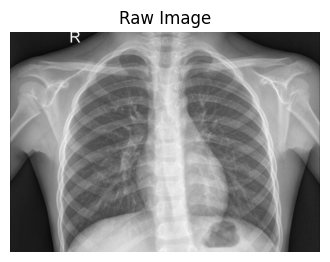

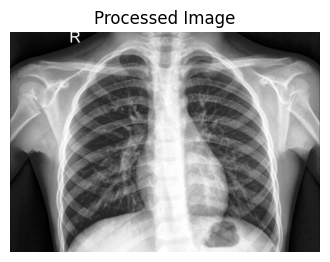

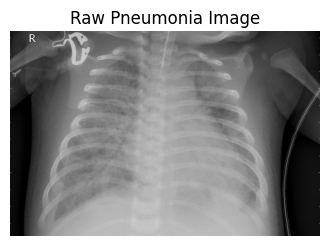

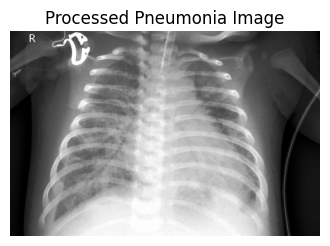

In [5]:
raw_normal_image_dir = "ChestXRay_Split/raw/train/NORMAL/NORMAL_00001.jpeg"
processed_normal_image_dir= "ChestXRay_Split/processed/train/NORMAL/NORMAL_00001.jpeg"

raw_puneumonia_image_dir = "ChestXRay_Split/raw/train/PNEUMONIA/PNEUMONIA_00001.jpeg"
processed_pneumonia_image_dir= "ChestXRay_Split/processed/train/PNEUMONIA/PNEUMONIA_00001.jpeg"

display_image(cv2.imread(raw_normal_image_dir), "Raw Image")
display_image(cv2.imread(processed_normal_image_dir), "Processed Image")
display_image(cv2.imread(raw_puneumonia_image_dir), "Raw Pneumonia Image")
display_image(cv2.imread(processed_pneumonia_image_dir), "Processed Pneumonia Image")

## 4- Feature extraction

In [13]:
def extract_edge_features(gray):
    edges = cv2.Canny(gray, 100, 200)
    return [np.mean(edges), np.std(edges)]

In [14]:
def extract_contour_features(gray):
    contours, _ = cv2.findContours(gray, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if contours:
        largest = max(contours, key=cv2.contourArea)
        area = cv2.contourArea(largest)
        perimeter = cv2.arcLength(largest, True)
        return [area, perimeter]
    else:
        return [0, 0]

In [15]:
def extract_features_from_image(img_path):
    gray = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)
    if gray is None:
        return None
    edge_feat = extract_edge_features(gray)
    contour_feat = extract_contour_features(gray)
    return edge_feat + contour_feat

In [16]:
def process_dataset_folder(base_dir):
    dataset = {'train': [], 'val': [], 'test': []}
    labels = {'train': [], 'val': [], 'test': []}
    label_map = {'NORMAL': 0, 'PNEUMONIA': 1}

    for split in ['train', 'val', 'test']:
        for cls in ['NORMAL', 'PNEUMONIA']:
            class_dir = Path(base_dir) / split / cls
            for img_path in class_dir.glob("*.*"):
                features = extract_features_from_image(img_path)
                if features:
                    dataset[split].append(features)
                    labels[split].append(label_map[cls])

    return dataset, labels

In [17]:
processed_path = "ChestXRay_Split/processed"
processed_features, processed_labels = process_dataset_folder(processed_path)

# Save features to file for later use
with open("features_processed.pkl", "wb") as f:
    pickle.dump({'features': processed_features, 'labels': processed_labels}, f)

In [18]:
raw_path = "ChestXRay_Split/raw"
raw_features, raw_labels = process_dataset_folder(raw_path)

# Save features to file for later use
with open("features_raw.pkl", "wb") as f:
    pickle.dump({'features': raw_features, 'labels': raw_labels}, f)

## 5- Classification 

## 6- Deep learning comparison (if possible)

## 7- Evaluation

## 8- Analysis and discussion